# 🧠 Denoising Autoencoder on MNIST
**Week 7 Project — RAG & Deep Learning Assignment**

---

## 📋 Assignment Tasks
1. Load and preprocess the MNIST dataset  
2. Add artificial noise to create noisy input images  
3. Build and train a Denoising Autoencoder (encoder + decoder)  
4. Generate denoised outputs on the test set  
5. Visualize original vs noisy vs reconstructed images  
6. Analyze results, challenges, and key observations  

---
**Evaluation Focus:** Data prep · Model architecture · Training setup · Denoising performance · Visualization · Analysis · Code quality

## 1. 📦 Setup & Imports

In [1]:
# ── Core libraries ────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── TensorFlow / Keras ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv2D, Conv2DTranspose, MaxPooling2D, UpSampling2D,
    Dense, Flatten, Reshape, BatchNormalization, Dropout, LeakyReLU
)
from tensorflow.keras.datasets import mnist
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ── Metrics ───────────────────────────────────────────────────────────────────
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity   as ssim

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print('All imports successful ✅')

TensorFlow : 2.20.0
NumPy      : 1.26.4
All imports successful ✅


## 2. 📂 Load & Preprocess MNIST Dataset

In [2]:
# ── Load MNIST ────────────────────────────────────────────────────────────────
(X_train_raw, y_train), (X_test_raw, y_test) = mnist.load_data()

print(f'Train images : {X_train_raw.shape}  |  Labels: {y_train.shape}')
print(f'Test  images : {X_test_raw.shape}  |  Labels: {y_test.shape}')
print(f'Pixel range  : [{X_train_raw.min()}, {X_train_raw.max()}]')

Train images : (60000, 28, 28)  |  Labels: (60000,)
Test  images : (10000, 28, 28)  |  Labels: (10000,)
Pixel range  : [0, 255]


In [3]:
# ── Preprocessing ─────────────────────────────────────────────────────────────
# 1. Normalize to [0, 1]
# 2. Add channel dimension for Conv2D: (N, 28, 28) → (N, 28, 28, 1)

X_train_clean = X_train_raw.astype('float32') / 255.0
X_test_clean  = X_test_raw.astype('float32')  / 255.0

X_train_clean = X_train_clean[..., np.newaxis]   # (60000, 28, 28, 1)
X_test_clean  = X_test_clean[..., np.newaxis]    # (10000, 28, 28, 1)

print(f'Clean train shape : {X_train_clean.shape}')
print(f'Clean test  shape : {X_test_clean.shape}')
print(f'Pixel range after normalisation: [{X_train_clean.min():.1f}, {X_train_clean.max():.1f}]')

Clean train shape : (60000, 28, 28, 1)
Clean test  shape : (10000, 28, 28, 1)
Pixel range after normalisation: [0.0, 1.0]


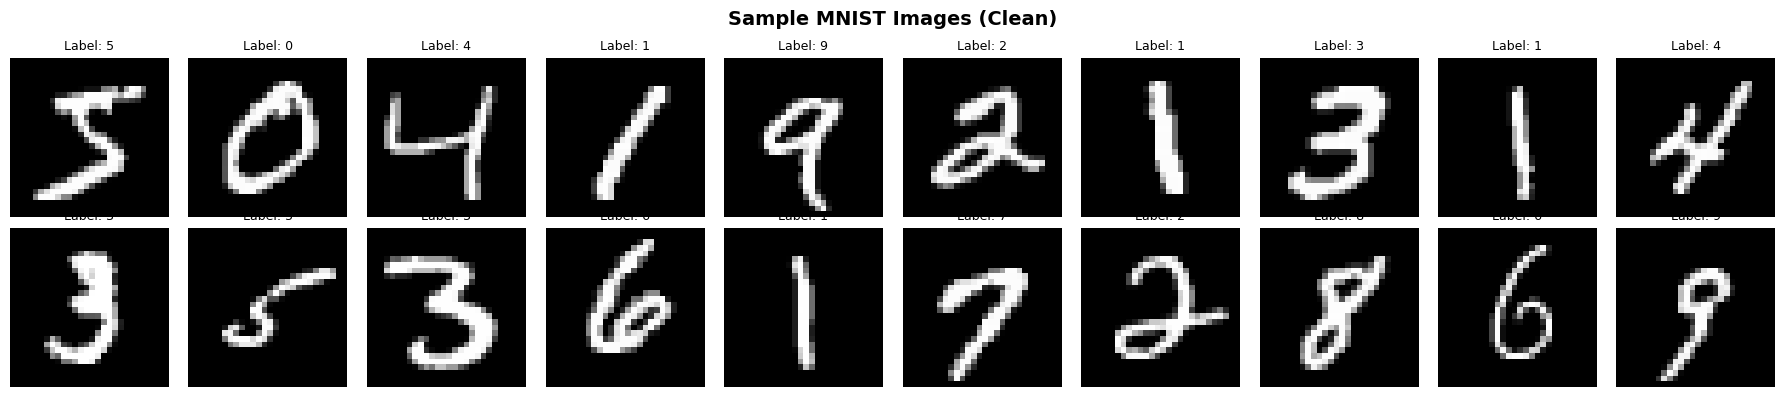

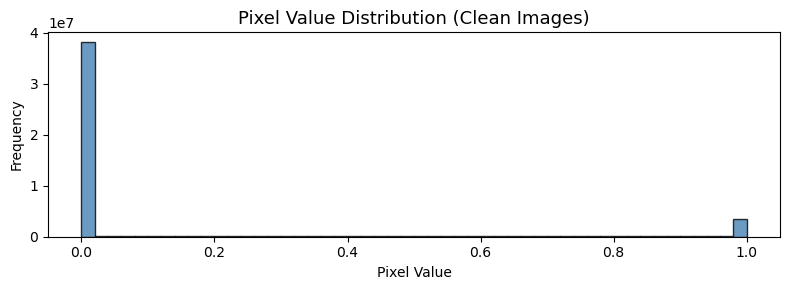

In [4]:
# ── Visualise a few clean samples ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle('Sample MNIST Images (Clean)', fontsize=14, fontweight='bold')
for i in range(10):
    axes[0, i].imshow(X_train_clean[i, :, :, 0], cmap='gray')
    axes[0, i].set_title(f'Label: {y_train[i]}', fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(X_train_clean[i+10, :, :, 0], cmap='gray')
    axes[1, i].set_title(f'Label: {y_train[i+10]}', fontsize=9)
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

# Pixel distribution
plt.figure(figsize=(8, 3))
plt.hist(X_train_clean.flatten(), bins=50, color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Pixel Value Distribution (Clean Images)', fontsize=13)
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 3. 🌫️ Add Artificial Noise

In [5]:
# ── Three noise types for experimentation ─────────────────────────────────────

def add_gaussian_noise(images, noise_factor=0.5):
    """Add Gaussian (random) noise — most common for denoising autoencoders."""
    noise  = np.random.normal(loc=0.0, scale=noise_factor, size=images.shape)
    noisy  = images + noise
    return np.clip(noisy, 0.0, 1.0).astype('float32')

def add_salt_pepper_noise(images, salt_prob=0.05, pepper_prob=0.05):
    """Add Salt & Pepper noise — random white/black pixels."""
    noisy = images.copy()
    rnd   = np.random.rand(*images.shape)
    noisy[rnd < salt_prob]                       = 1.0   # Salt (white)
    noisy[(rnd >= salt_prob) & (rnd < salt_prob + pepper_prob)] = 0.0   # Pepper (black)
    return np.clip(noisy, 0.0, 1.0).astype('float32')

def add_speckle_noise(images, noise_factor=0.4):
    """Add Speckle (multiplicative) noise."""
    noise = np.random.randn(*images.shape) * noise_factor
    noisy = images + images * noise
    return np.clip(noisy, 0.0, 1.0).astype('float32')

# ── Generate noisy datasets (Gaussian is primary — used for training) ─────────
NOISE_FACTOR = 0.5

X_train_noisy_gauss = add_gaussian_noise(X_train_clean,   NOISE_FACTOR)
X_test_noisy_gauss  = add_gaussian_noise(X_test_clean,    NOISE_FACTOR)

X_test_noisy_sp     = add_salt_pepper_noise(X_test_clean, 0.05, 0.05)
X_test_noisy_spk    = add_speckle_noise(X_test_clean,     0.4)

print(f'Noisy train (Gaussian) : {X_train_noisy_gauss.shape}')
print(f'Noisy test  (Gaussian) : {X_test_noisy_gauss.shape}')
print(f'Noise factor           : {NOISE_FACTOR}')

Noisy train (Gaussian) : (60000, 28, 28, 1)
Noisy test  (Gaussian) : (10000, 28, 28, 1)
Noise factor           : 0.5


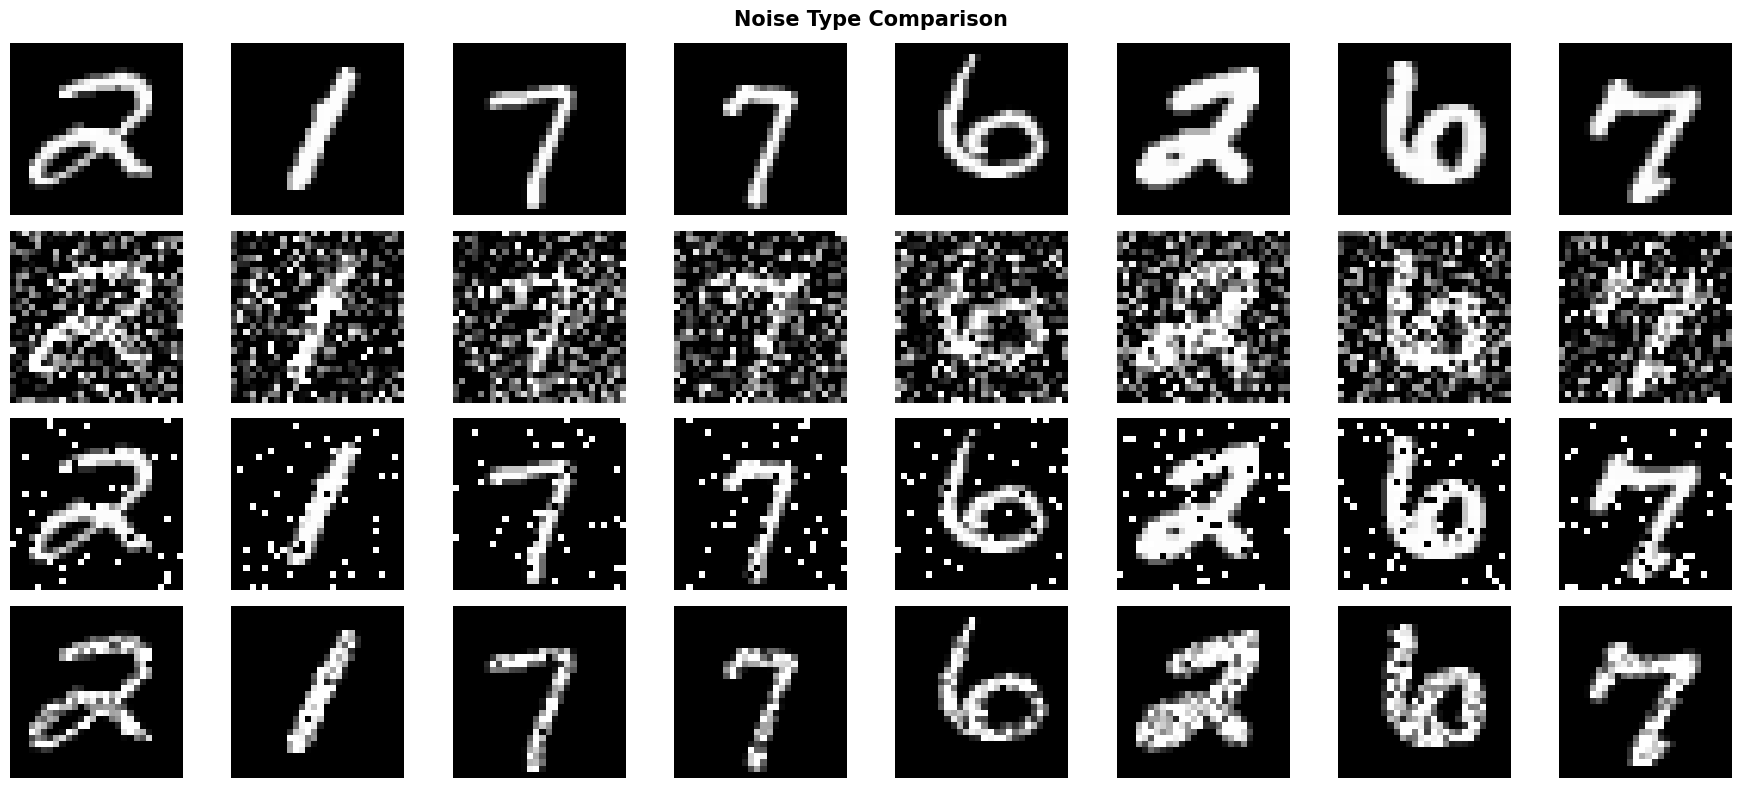

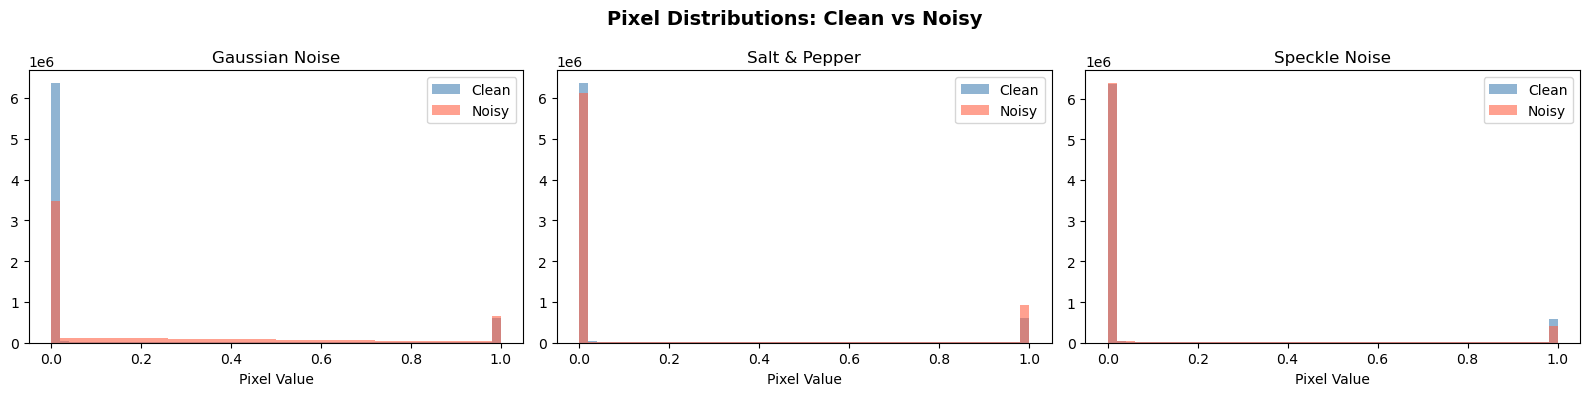

In [6]:
# ── Visualise different noise types ───────────────────────────────────────────
n_samples = 8
idx = np.random.choice(len(X_test_clean), n_samples, replace=False)

fig, axes = plt.subplots(4, n_samples, figsize=(18, 8))
row_labels = ['Clean', 'Gaussian Noise', 'Salt & Pepper', 'Speckle Noise']
data_rows  = [X_test_clean, X_test_noisy_gauss, X_test_noisy_sp, X_test_noisy_spk]

for row, (label, data) in enumerate(zip(row_labels, data_rows)):
    for col, i in enumerate(idx):
        axes[row, col].imshow(data[i, :, :, 0], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(label, fontsize=11, fontweight='bold', rotation=90, labelpad=50)

fig.suptitle('Noise Type Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Pixel distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
titles = ['Gaussian Noise', 'Salt & Pepper', 'Speckle Noise']
noisy_sets = [X_test_noisy_gauss, X_test_noisy_sp, X_test_noisy_spk]

for ax, title, noisy in zip(axes, titles, noisy_sets):
    ax.hist(X_test_clean.flatten(), bins=50, alpha=0.6, color='steelblue', label='Clean')
    ax.hist(noisy.flatten(),        bins=50, alpha=0.6, color='tomato',    label='Noisy')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Pixel Value')
    ax.legend()

fig.suptitle('Pixel Distributions: Clean vs Noisy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. 🏗️ Build the Denoising Autoencoder

We implement **two architectures**:
- **Model A** — Dense (fully connected) Autoencoder: baseline
- **Model B** — Convolutional Autoencoder (main model): better spatial feature learning

In [7]:
# ════════════════════════════════════════════════════════════════════════════
#  MODEL A — Dense (Fully Connected) Autoencoder  [Baseline]
# ════════════════════════════════════════════════════════════════════════════

def build_dense_autoencoder(input_shape=(28, 28, 1), latent_dim=64):
    """
    Architecture:
      Encoder: Flatten → Dense(256) → Dense(128) → Dense(latent_dim)
      Decoder: Dense(128) → Dense(256) → Dense(784) → Reshape(28,28,1)
    """
    inp = Input(shape=input_shape, name='encoder_input')

    # ── Encoder ──────────────────────────────────────────────────────────────
    x = Flatten()(inp)
    x = Dense(256, activation='relu', name='enc_dense1')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = Dense(128, activation='relu', name='enc_dense2')(x)
    x = BatchNormalization()(x)
    encoded = Dense(latent_dim, activation='relu', name='latent')(x)

    # ── Decoder ──────────────────────────────────────────────────────────────
    x = Dense(128, activation='relu', name='dec_dense1')(encoded)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu', name='dec_dense2')(x)
    x = BatchNormalization()(x)
    x = Dense(28*28, activation='sigmoid', name='dec_output')(x)
    decoded = Reshape((28, 28, 1), name='output_reshape')(x)

    model = Model(inputs=inp, outputs=decoded, name='Dense_Autoencoder')
    return model


dense_ae = build_dense_autoencoder(latent_dim=64)
dense_ae.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='mse'
)
dense_ae.summary()

Model: "Dense_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_dense1 (Dense)                   │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_dense2 (Dense)                   │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ latent (Dense)                       │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dec_dense1 (Dense)                   │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dec_dense2 (Dense)                   │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dec_output (Dense)                   │ (None, 784)                 │         201,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_reshape (Reshape)             │ (None, 28, 28, 1)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 488,016 (1.86 MB)

 Trainable params: 486,480 (1.86 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [8]:
# ════════════════════════════════════════════════════════════════════════════
#  MODEL B — Convolutional Autoencoder  [MAIN MODEL]
# ════════════════════════════════════════════════════════════════════════════

def build_conv_autoencoder(input_shape=(28, 28, 1)):
    """
    Architecture:
      Encoder:
        Conv(32,3×3) → BN → MaxPool(2×2)    [28×28 → 14×14]
        Conv(64,3×3) → BN → MaxPool(2×2)    [14×14 →  7× 7]
        Conv(128,3×3) → BN                  [7×7, bottleneck]
      Decoder:
        Conv(64,3×3)  → BN → UpSample(2×2)  [ 7× 7 → 14×14]
        Conv(32,3×3)  → BN → UpSample(2×2)  [14×14 → 28×28]
        Conv(1, 3×3)  → sigmoid             [28×28, output]
    """
    inp = Input(shape=input_shape, name='input')

    # ── Encoder ──────────────────────────────────────────────────────────────
    x = Conv2D(32, (3, 3), padding='same', name='enc_conv1')(inp)
    x = LeakyReLU(alpha=0.1)(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), padding='same')(x)   # 28→14

    x = Conv2D(64, (3, 3), padding='same', name='enc_conv2')(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), padding='same')(x)   # 14→7

    x = Conv2D(128, (3, 3), padding='same', name='bottleneck')(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = BatchNormalization()(x)
    # Shape here: (batch, 7, 7, 128)

    # ── Decoder ──────────────────────────────────────────────────────────────
    x = Conv2D(64, (3, 3), padding='same', name='dec_conv1')(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2))(x)                  # 7→14

    x = Conv2D(32, (3, 3), padding='same', name='dec_conv2')(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2))(x)                  # 14→28

    decoded = Conv2D(1, (3, 3), padding='same', activation='sigmoid', name='output')(x)

    model = Model(inputs=inp, outputs=decoded, name='Conv_Autoencoder')
    return model


conv_ae = build_conv_autoencoder()
conv_ae.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='mse'
)
conv_ae.summary()

Model: "Conv_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_conv1 (Conv2D)                   │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_conv2 (Conv2D)                   │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bottleneck (Conv2D)                  │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 7, 7, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dec_conv1 (Conv2D)                   │ (None, 7, 7, 64)            │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 7, 7, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dec_conv2 (Conv2D)                   │ (None, 14, 14, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_4 (LeakyReLU)            │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 14, 14, 32)          │             128 │
│ (BatchNormalization)                 │                             │              

 Total params: 186,497 (728.50 KB)

 Trainable params: 185,857 (726.00 KB)

 Non-trainable params: 640 (2.50 KB)

In [9]:
# ── Architecture diagram (text) ───────────────────────────────────────────────
print('\n' + '='*60)
print('  CONVOLUTIONAL AUTOENCODER — Architecture Flow')
print('='*60)
print('''
  INPUT  (28×28×1)
      │
  ┌───────────────── ENCODER ─────────────────┐
  │  Conv2D(32, 3×3) + BN + LeakyReLU        │
  │  MaxPool(2×2) → (14×14×32)               │
  │                                           │
  │  Conv2D(64, 3×3) + BN + LeakyReLU        │
  │  MaxPool(2×2) → (7×7×64)                 │
  │                                           │
  │  Conv2D(128, 3×3) + BN + LeakyReLU       │
  │  BOTTLENECK → (7×7×128)  [6272 values]   │
  └───────────────────────────────────────────┘
      │
  ┌───────────────── DECODER ─────────────────┐
  │  Conv2D(64, 3×3) + BN + LeakyReLU        │
  │  UpSampling(2×2) → (14×14×64)            │
  │                                           │
  │  Conv2D(32, 3×3) + BN + LeakyReLU        │
  │  UpSampling(2×2) → (28×28×32)            │
  │                                           │
  │  Conv2D(1, 3×3) + sigmoid                │
  │  OUTPUT → (28×28×1)                      │
  └───────────────────────────────────────────┘
''')


  CONVOLUTIONAL AUTOENCODER — Architecture Flow

  INPUT  (28×28×1)
      │
  ┌───────────────── ENCODER ─────────────────┐
  │  Conv2D(32, 3×3) + BN + LeakyReLU        │
  │  MaxPool(2×2) → (14×14×32)               │
  │                                           │
  │  Conv2D(64, 3×3) + BN + LeakyReLU        │
  │  MaxPool(2×2) → (7×7×64)                 │
  │                                           │
  │  Conv2D(128, 3×3) + BN + LeakyReLU       │
  │  BOTTLENECK → (7×7×128)  [6272 values]   │
  └───────────────────────────────────────────┘
      │
  ┌───────────────── DECODER ─────────────────┐
  │  Conv2D(64, 3×3) + BN + LeakyReLU        │
  │  UpSampling(2×2) → (14×14×64)            │
  │                                           │
  │  Conv2D(32, 3×3) + BN + LeakyReLU        │
  │  UpSampling(2×2) → (28×28×32)            │
  │                                           │
  │  Conv2D(1, 3×3) + sigmoid                │
  │  OUTPUT → (28×28×1)                      │
  └────────────

## 5. 🏋️ Train the Autoencoder

In [10]:
# ── Training callbacks ────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# ── Train Dense Autoencoder (baseline) ───────────────────────────────────────
print('Training Dense Autoencoder (Baseline)…')
print('─'*50)
hist_dense = dense_ae.fit(
    X_train_noisy_gauss, X_train_clean,       # input=noisy, target=clean
    epochs=30,
    batch_size=256,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)
print('Dense AE training complete ✅')

Training Dense Autoencoder (Baseline)…
──────────────────────────────────────────────────
Epoch 1/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - loss: 0.0893 - val_loss: 0.0425 - learning_rate: 0.0010
Epoch 2/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.0290 - val_loss: 0.0267 - learning_rate: 0.0010
Epoch 3/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.0243 - val_loss: 0.0221 - learning_rate: 0.0010
Epoch 4/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - loss: 0.0218 - val_loss: 0.0200 - learning_rate: 0.0010
Epoch 5/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 0.0203 - val_loss: 0.0188 - learning_rate: 0.0010
Epoch 6/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0192 - val_loss: 0.0177 - learning_rate: 0.0010
Epoch 7/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 0.0184 - val_loss: 0.0172 - learning_rate: 0.0010
Epoch 8/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 0.0178 - val_loss: 0.0166 - learning_rate: 0.0010
Epoch 9/30
211/2

In [11]:
# ── Train Convolutional Autoencoder (main model) ──────────────────────────────
print('Training Convolutional Autoencoder (Main Model)…')
print('─'*50)
hist_conv = conv_ae.fit(
    X_train_noisy_gauss, X_train_clean,       # input=noisy, target=clean
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)
print('Conv AE training complete ✅')

Training Convolutional Autoencoder (Main Model)…
──────────────────────────────────────────────────
Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 115s 515ms/step - loss: 0.0359 - val_loss: 0.1445 - learning_rate: 0.0010
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 137s 492ms/step - loss: 0.0140 - val_loss: 0.0422 - learning_rate: 0.0010
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - loss: 0.0124  
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
211/211 ━━━━━━━━━━━━━━━━━━━━ 105s 498ms/step - loss: 0.0122 - val_loss: 0.0137 - learning_rate: 0.0010
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 105s 496ms/step - loss: 0.0115 - val_loss: 0.0114 - learning_rate: 5.0000e-04
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 142s 499ms/step - loss: 0.0112 - val_loss: 0.0112 - learning_rate: 5.0000e-04
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 102s 484ms/step - loss: 0.0110 - val_loss: 0.0111 - learning_rate: 5.0000e-04
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 144s 494ms/step - loss: 0.01

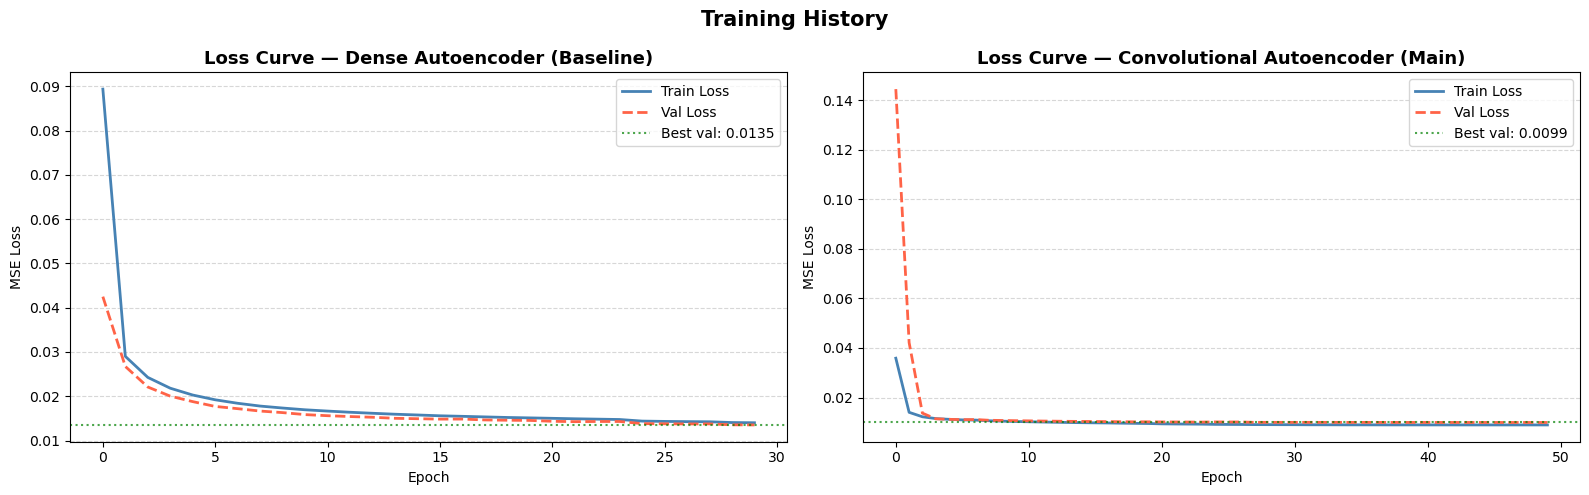

Best Dense AE val_loss  : 0.013516
Best Conv  AE val_loss  : 0.009927


In [12]:
# ── Plot Training & Validation Loss ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, hist, title in zip(
    axes,
    [hist_dense, hist_conv],
    ['Dense Autoencoder (Baseline)', 'Convolutional Autoencoder (Main)']
):
    ax.plot(hist.history['loss'],     label='Train Loss', color='steelblue', linewidth=2)
    ax.plot(hist.history['val_loss'], label='Val Loss',   color='tomato',    linewidth=2, linestyle='--')
    ax.set_title(f'Loss Curve — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    min_val = min(hist.history['val_loss'])
    ax.axhline(min_val, color='green', linestyle=':', alpha=0.7, label=f'Best val: {min_val:.4f}')
    ax.legend(fontsize=10)

plt.suptitle('Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Best Dense AE val_loss  : {min(hist_dense.history["val_loss"]):.6f}')
print(f'Best Conv  AE val_loss  : {min(hist_conv.history["val_loss"]):.6f}')

## 6. 🔍 Generate Denoised Outputs on Test Set

In [13]:
# ── Predict on test set ───────────────────────────────────────────────────────
print('Generating denoised outputs…')

# Gaussian noisy inputs
X_test_denoised_dense = dense_ae.predict(X_test_noisy_gauss, batch_size=512, verbose=0)
X_test_denoised_conv  = conv_ae.predict(X_test_noisy_gauss,  batch_size=512, verbose=0)

# Cross-noise test (model trained on Gaussian; tested on S&P and Speckle)
X_test_denoised_sp  = conv_ae.predict(X_test_noisy_sp,  batch_size=512, verbose=0)
X_test_denoised_spk = conv_ae.predict(X_test_noisy_spk, batch_size=512, verbose=0)

print('Denoised outputs generated ✅')
print(f'Output shape: {X_test_denoised_conv.shape}')

Generating denoised outputs…
Denoised outputs generated ✅
Output shape: (10000, 28, 28, 1)


## 7. 📊 Quantitative Evaluation Metrics

In [14]:
# ── Compute PSNR, SSIM, MSE on a sample of test images ───────────────────────
def compute_metrics(clean, noisy, denoised, n_samples=1000):
    """Compute avg PSNR, SSIM, MSE for noisy and denoised vs clean."""
    idx = np.random.choice(len(clean), n_samples, replace=False)
    psnr_noisy_list, psnr_denoised_list = [], []
    ssim_noisy_list, ssim_denoised_list = [], []
    mse_noisy_list,  mse_denoised_list  = [], []

    for i in idx:
        c = clean[i, :, :, 0]
        n = noisy[i, :, :, 0]
        d = denoised[i, :, :, 0]

        psnr_noisy_list.append(psnr(c, n,   data_range=1.0))
        psnr_denoised_list.append(psnr(c, d, data_range=1.0))

        ssim_noisy_list.append(ssim(c, n,    data_range=1.0))
        ssim_denoised_list.append(ssim(c, d, data_range=1.0))

        mse_noisy_list.append(np.mean((c - n)**2))
        mse_denoised_list.append(np.mean((c - d)**2))

    return {
        'PSNR_noisy'   : np.mean(psnr_noisy_list),
        'PSNR_denoised': np.mean(psnr_denoised_list),
        'SSIM_noisy'   : np.mean(ssim_noisy_list),
        'SSIM_denoised': np.mean(ssim_denoised_list),
        'MSE_noisy'    : np.mean(mse_noisy_list),
        'MSE_denoised' : np.mean(mse_denoised_list),
    }

print('Computing metrics…')
m_dense = compute_metrics(X_test_clean, X_test_noisy_gauss, X_test_denoised_dense)
m_conv  = compute_metrics(X_test_clean, X_test_noisy_gauss, X_test_denoised_conv)

import pandas as pd
metrics_df = pd.DataFrame({
    'Metric'          : ['PSNR (dB) ↑', 'SSIM ↑', 'MSE ↓'],
    'Noisy Input'     : [m_dense['PSNR_noisy'],    m_dense['SSIM_noisy'],    m_dense['MSE_noisy']],
    'Dense AE Output' : [m_dense['PSNR_denoised'], m_dense['SSIM_denoised'], m_dense['MSE_denoised']],
    'Conv AE Output'  : [m_conv['PSNR_denoised'],  m_conv['SSIM_denoised'],  m_conv['MSE_denoised']],
})
metrics_df = metrics_df.set_index('Metric').round(4)
print('\n=== Quantitative Results ===')
print(metrics_df.to_string())

Computing metrics…

=== Quantitative Results ===
             Noisy Input  Dense AE Output  Conv AE Output
Metric                                                   
PSNR (dB) ↑       9.3969          19.2247         20.5318
SSIM ↑            0.3764           0.8215          0.8691
MSE ↓             0.1152           0.0132          0.0096


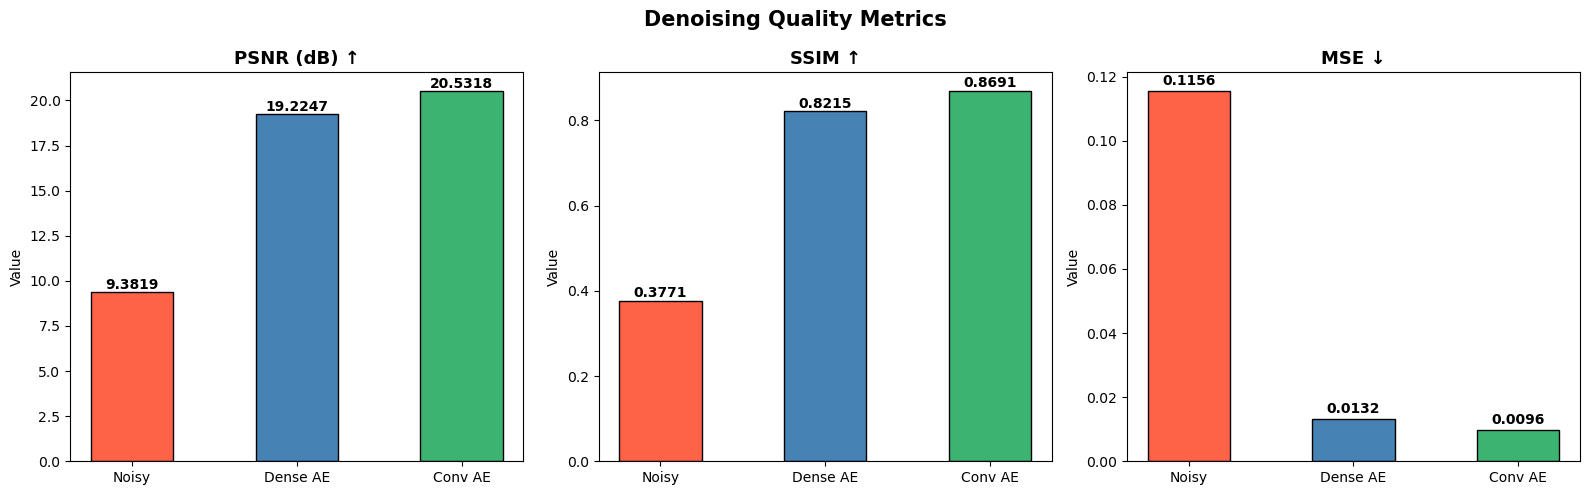

In [15]:
# ── Metrics bar chart ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metric_names = ['PSNR (dB) ↑', 'SSIM ↑', 'MSE ↓']
noisy_vals   = [m_conv['PSNR_noisy'],    m_conv['SSIM_noisy'],    m_conv['MSE_noisy']]
dense_vals   = [m_dense['PSNR_denoised'],m_dense['SSIM_denoised'],m_dense['MSE_denoised']]
conv_vals    = [m_conv['PSNR_denoised'], m_conv['SSIM_denoised'], m_conv['MSE_denoised']]

x = np.arange(1)
width = 0.25
colors = ['tomato', 'steelblue', 'mediumseagreen']
labels = ['Noisy Input', 'Dense AE', 'Conv AE']

for i, (ax, mname, nv, dv, cv) in enumerate(zip(axes, metric_names, noisy_vals, dense_vals, conv_vals)):
    bars = ax.bar(['Noisy', 'Dense AE', 'Conv AE'], [nv, dv, cv],
                  color=colors, edgecolor='black', width=0.5)
    ax.set_title(mname, fontsize=13, fontweight='bold')
    ax.set_ylabel('Value')
    for bar, val in zip(bars, [nv, dv, cv]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

fig.suptitle('Denoising Quality Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. 🖼️ Result Visualization — Original vs Noisy vs Reconstructed

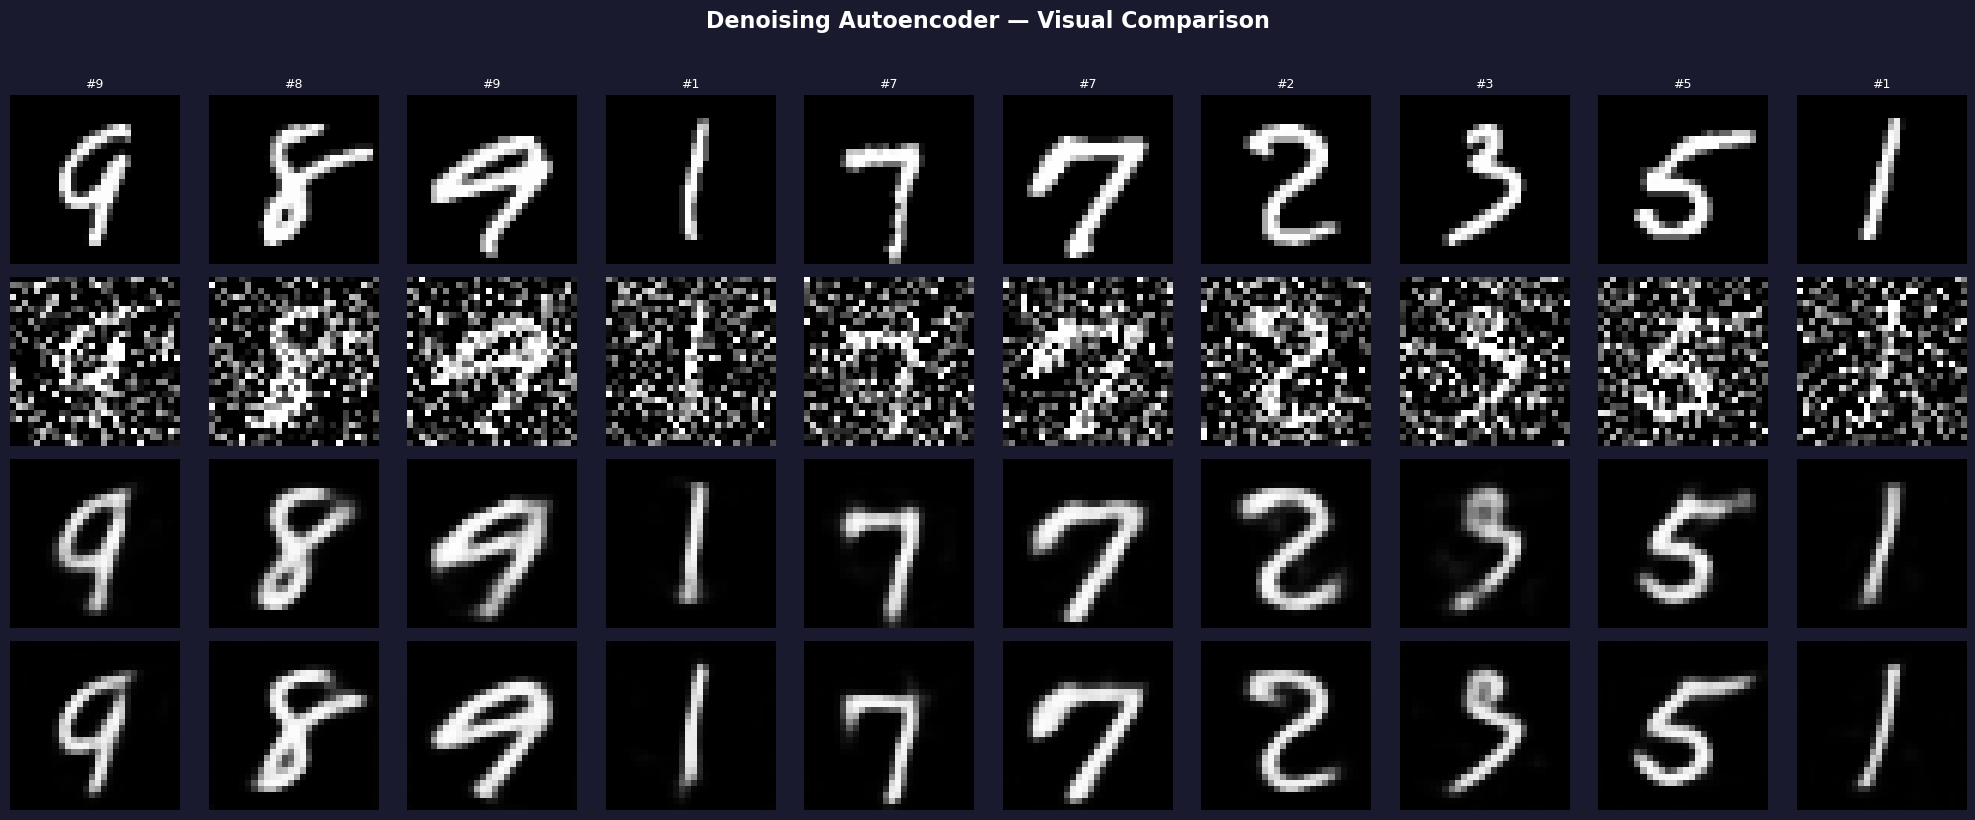

Figure saved as denoising_comparison.png ✅


In [16]:
# ── Main comparison: 5 rows × n_samples columns ──────────────────────────────
n_samples = 10
idx = np.random.choice(len(X_test_clean), n_samples, replace=False)

rows = [
    ('Original (Clean)',          X_test_clean),
    ('Noisy Input (Gaussian σ=0.5)', X_test_noisy_gauss),
    ('Dense AE Reconstructed',    X_test_denoised_dense),
    ('Conv AE Reconstructed',     X_test_denoised_conv),
]

fig, axes = plt.subplots(len(rows), n_samples, figsize=(20, 8))
fig.patch.set_facecolor('#1a1a2e')

row_colors = ['#16213e', '#0f3460', '#533483', '#1a472a']

for row_idx, (label, data) in enumerate(rows):
    for col_idx, i in enumerate(idx):
        ax = axes[row_idx, col_idx]
        ax.imshow(data[i, :, :, 0], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        ax.set_facecolor(row_colors[row_idx])
        if col_idx == 0:
            ax.set_ylabel(label, fontsize=9, color='white',
                          rotation=90, labelpad=45, fontweight='bold')
        if row_idx == 0:
            ax.set_title(f'#{y_test[i]}', fontsize=9, color='white')

fig.suptitle('Denoising Autoencoder — Visual Comparison', fontsize=16,
             fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('denoising_comparison.png', bbox_inches='tight',
            dpi=150, facecolor='#1a1a2e')
plt.show()
print('Figure saved as denoising_comparison.png ✅')

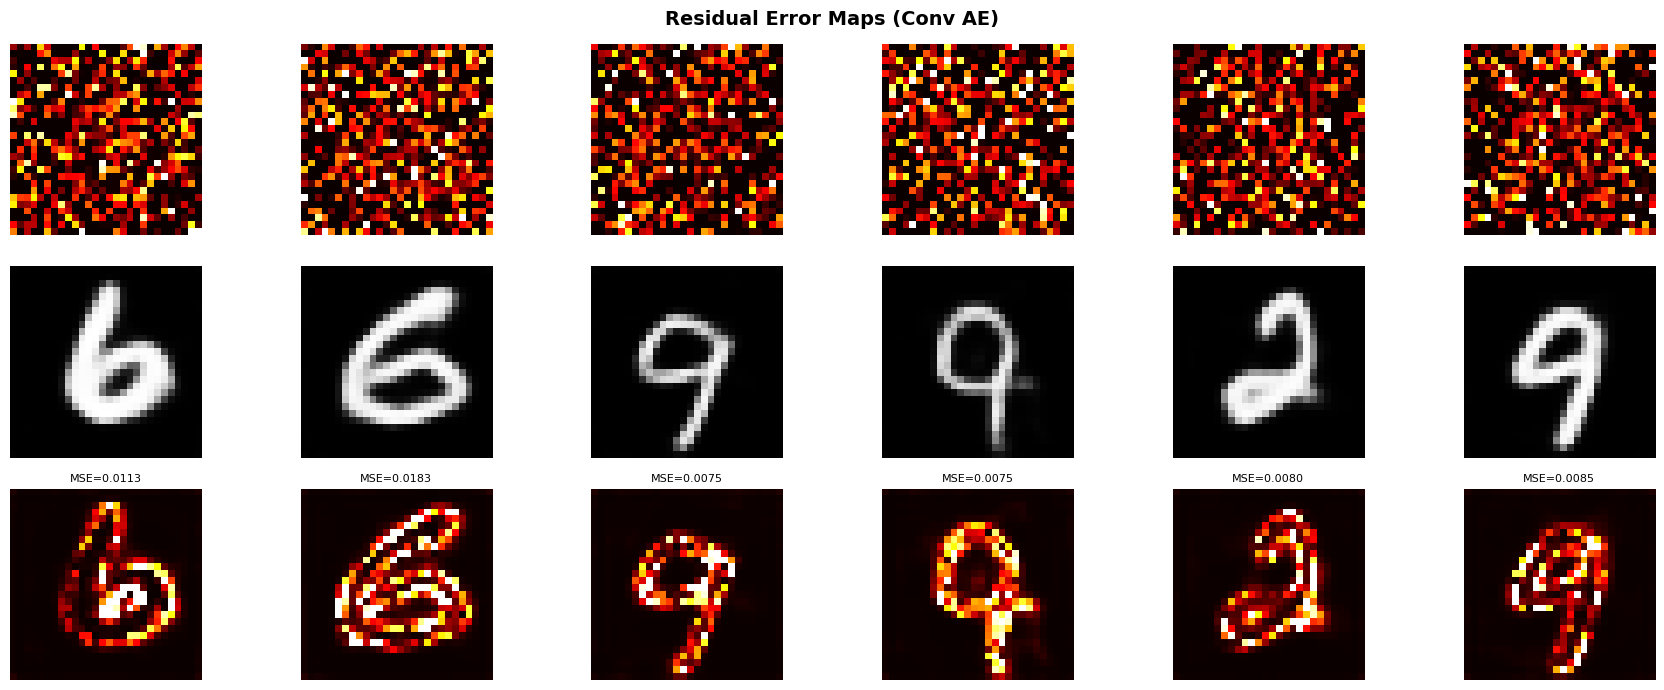

In [17]:
# ── Residual / Error maps ─────────────────────────────────────────────────────
# Shows WHERE the model makes errors (bright = large error)
n_show = 6
idx2   = np.random.choice(len(X_test_clean), n_show, replace=False)

fig, axes = plt.subplots(3, n_show, figsize=(18, 7))
for col, i in enumerate(idx2):
    clean   = X_test_clean[i, :, :, 0]
    noisy   = X_test_noisy_gauss[i, :, :, 0]
    denoised= X_test_denoised_conv[i, :, :, 0]

    # Row 0: noisy residual (what noise was added)
    axes[0, col].imshow(np.abs(clean - noisy), cmap='hot', vmin=0, vmax=1)
    axes[0, col].axis('off')
    if col == 0: axes[0, col].set_ylabel('Noise Added\n|Clean−Noisy|', fontsize=9)

    # Row 1: denoised output
    axes[1, col].imshow(denoised, cmap='gray', vmin=0, vmax=1)
    axes[1, col].axis('off')
    if col == 0: axes[1, col].set_ylabel('Conv AE Output', fontsize=9)

    # Row 2: reconstruction error
    axes[2, col].imshow(np.abs(clean - denoised), cmap='hot', vmin=0, vmax=0.3)
    err = np.mean((clean - denoised)**2)
    axes[2, col].set_title(f'MSE={err:.4f}', fontsize=8)
    axes[2, col].axis('off')
    if col == 0: axes[2, col].set_ylabel('Residual Error\n|Clean−Denoised|', fontsize=9)

fig.suptitle('Residual Error Maps (Conv AE)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

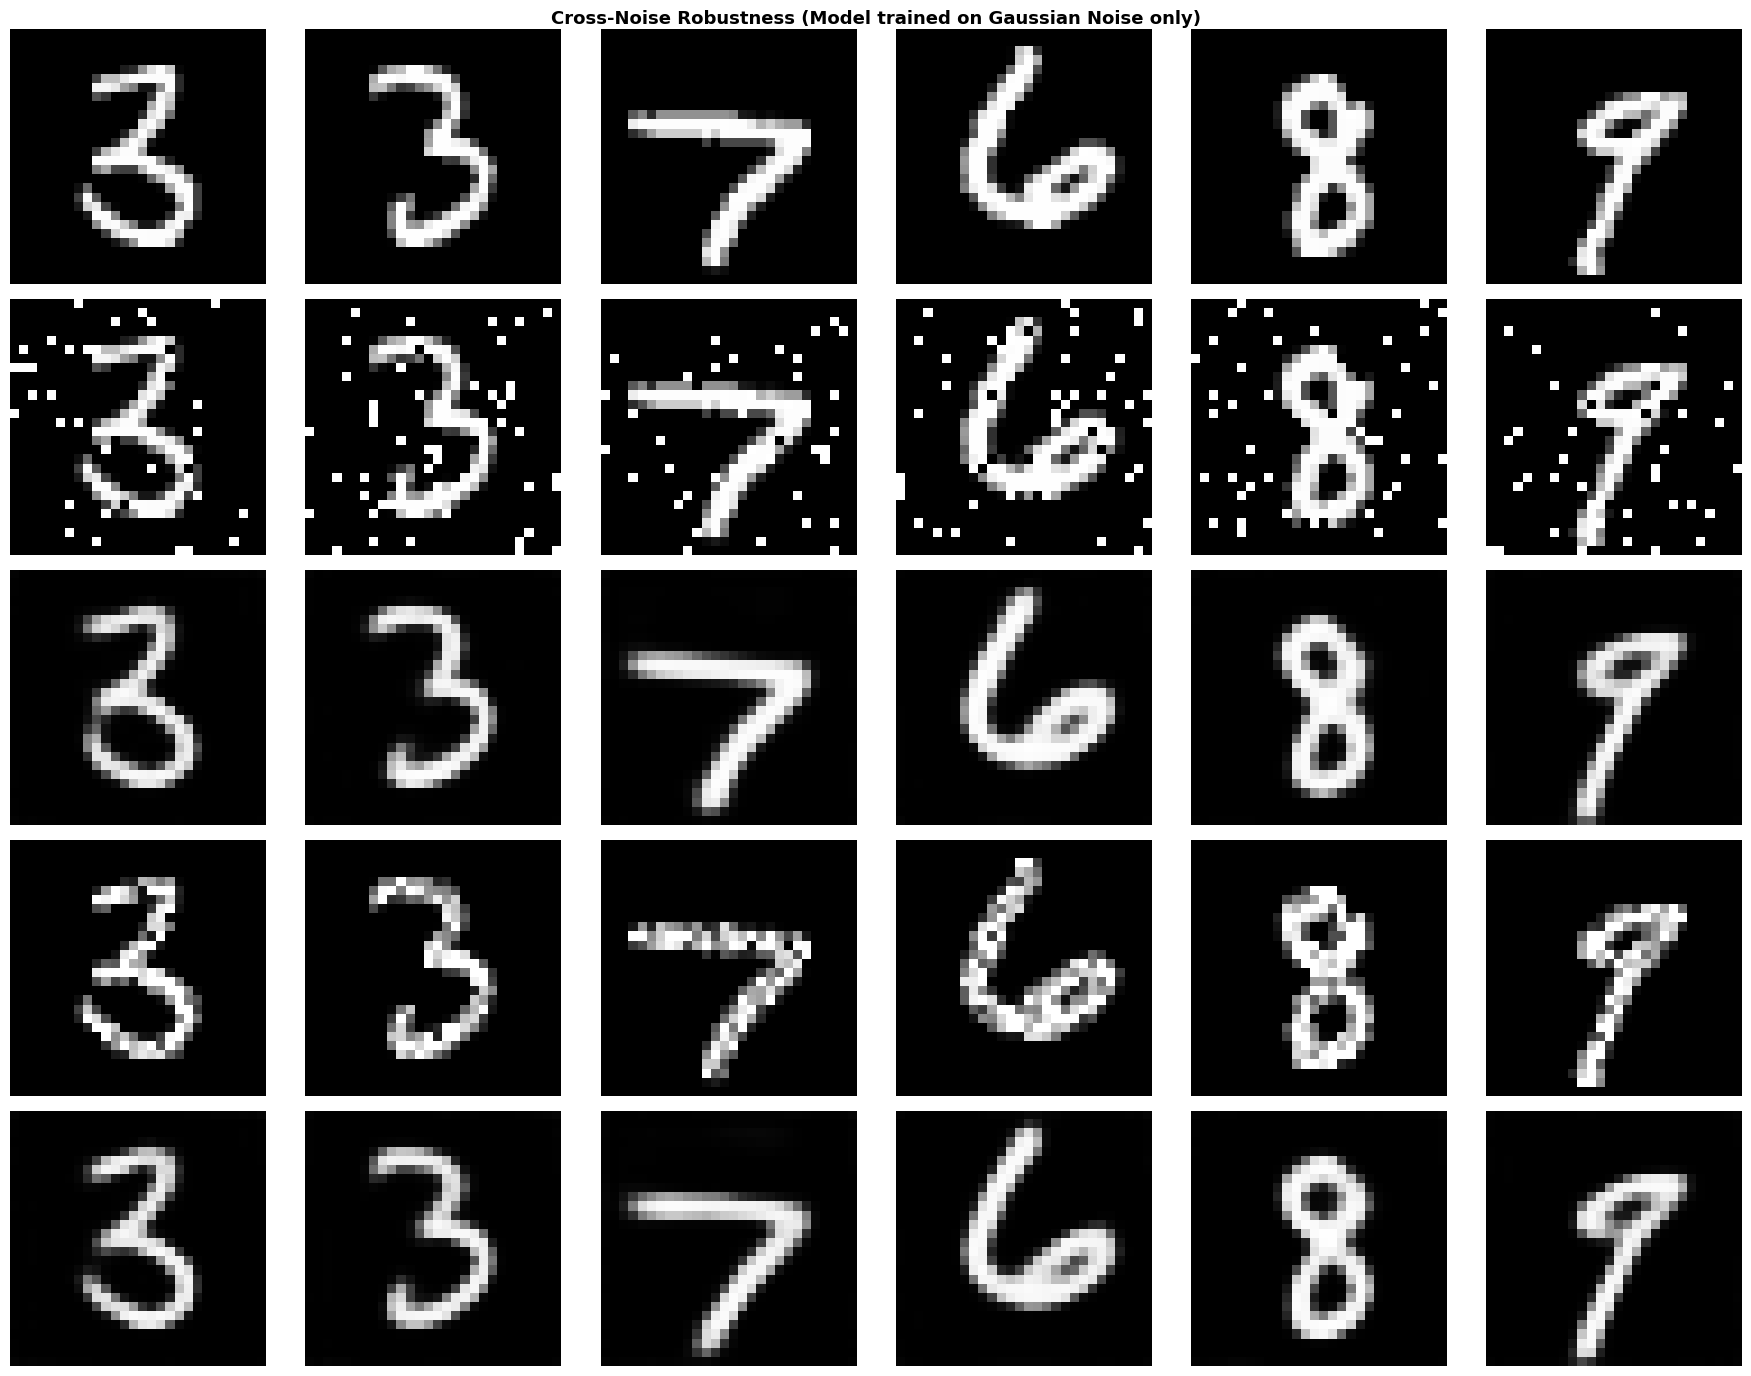

In [18]:
# ── Cross-noise robustness (trained on Gaussian, tested on S&P & Speckle) ────
n_show = 6
idx3   = np.random.choice(len(X_test_clean), n_show, replace=False)

fig, axes = plt.subplots(5, n_show, figsize=(18, 14))
rows_data = [
    ('Clean',                X_test_clean),
    ('Salt & Pepper (noisy)',X_test_noisy_sp),
    ('Conv AE → S&P',        X_test_denoised_sp),
    ('Speckle (noisy)',       X_test_noisy_spk),
    ('Conv AE → Speckle',    X_test_denoised_spk),
]
for row_idx, (label, data) in enumerate(rows_data):
    for col_idx, i in enumerate(idx3):
        axes[row_idx, col_idx].imshow(data[i, :, :, 0], cmap='gray', vmin=0, vmax=1)
        axes[row_idx, col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx, col_idx].set_ylabel(label, fontsize=9, fontweight='bold', labelpad=40)

fig.suptitle('Cross-Noise Robustness (Model trained on Gaussian Noise only)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. 🔬 Innovation — Noise Level Ablation Study

Noise σ=0.1  →  PSNR: 23.52 dB  |  SSIM: 0.9320
Noise σ=0.2  →  PSNR: 23.20 dB  |  SSIM: 0.9270
Noise σ=0.3  →  PSNR: 22.65 dB  |  SSIM: 0.9177
Noise σ=0.4  →  PSNR: 21.73 dB  |  SSIM: 0.9004
Noise σ=0.5  →  PSNR: 20.57 dB  |  SSIM: 0.8676
Noise σ=0.6  →  PSNR: 19.13 dB  |  SSIM: 0.8115
Noise σ=0.7  →  PSNR: 17.63 dB  |  SSIM: 0.7330
Noise σ=0.8  →  PSNR: 16.09 dB  |  SSIM: 0.6441


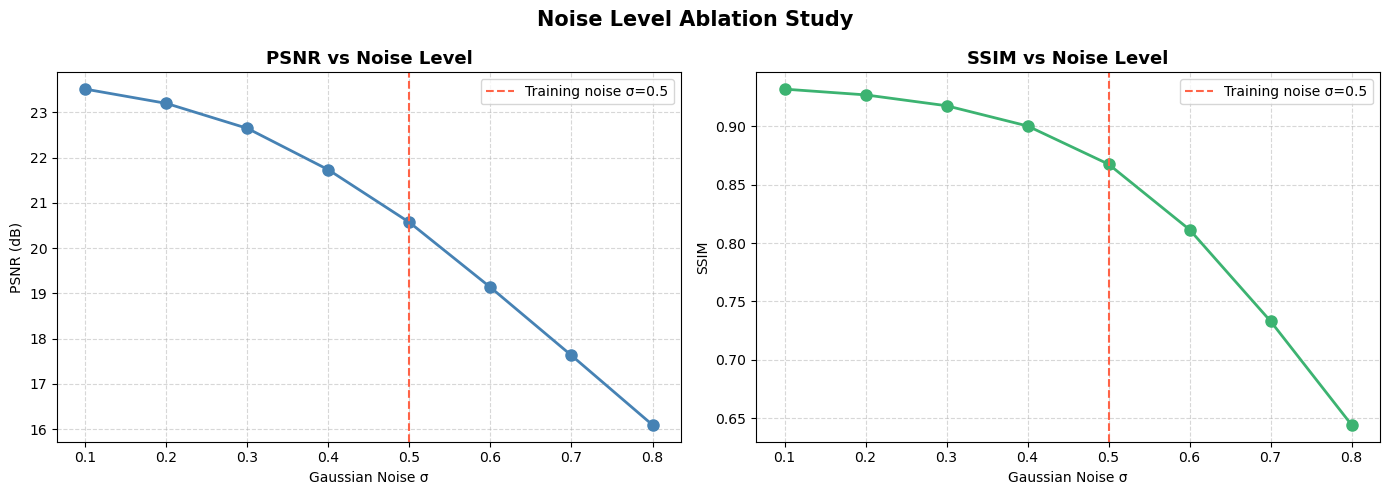

In [19]:
# ── How does the model perform at different noise intensities? ────────────────
noise_levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
psnr_results = []
ssim_results = []

sample_idx = np.random.choice(len(X_test_clean), 500, replace=False)
clean_sample = X_test_clean[sample_idx]

for nf in noise_levels:
    noisy_sample    = add_gaussian_noise(clean_sample, nf)
    denoised_sample = conv_ae.predict(noisy_sample, batch_size=256, verbose=0)

    p_vals, s_vals = [], []
    for i in range(len(clean_sample)):
        c = clean_sample[i, :, :, 0]
        d = denoised_sample[i, :, :, 0]
        p_vals.append(psnr(c, d, data_range=1.0))
        s_vals.append(ssim(c, d, data_range=1.0))

    psnr_results.append(np.mean(p_vals))
    ssim_results.append(np.mean(s_vals))
    print(f'Noise σ={nf:.1f}  →  PSNR: {np.mean(p_vals):.2f} dB  |  SSIM: {np.mean(s_vals):.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(noise_levels, psnr_results, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].axvline(NOISE_FACTOR, color='tomato', linestyle='--', label=f'Training noise σ={NOISE_FACTOR}')
axes[0].set_title('PSNR vs Noise Level', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gaussian Noise σ')
axes[0].set_ylabel('PSNR (dB)')
axes[0].legend()
axes[0].grid(linestyle='--', alpha=0.5)

axes[1].plot(noise_levels, ssim_results, 'o-', color='mediumseagreen', linewidth=2, markersize=8)
axes[1].axvline(NOISE_FACTOR, color='tomato', linestyle='--', label=f'Training noise σ={NOISE_FACTOR}')
axes[1].set_title('SSIM vs Noise Level', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Gaussian Noise σ')
axes[1].set_ylabel('SSIM')
axes[1].legend()
axes[1].grid(linestyle='--', alpha=0.5)

fig.suptitle('Noise Level Ablation Study', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Running t-SNE (clean latent space)…


  File "C:\Users\saksh\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\saksh\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\saksh\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\saksh\anaconda3\Lib\subprocess.

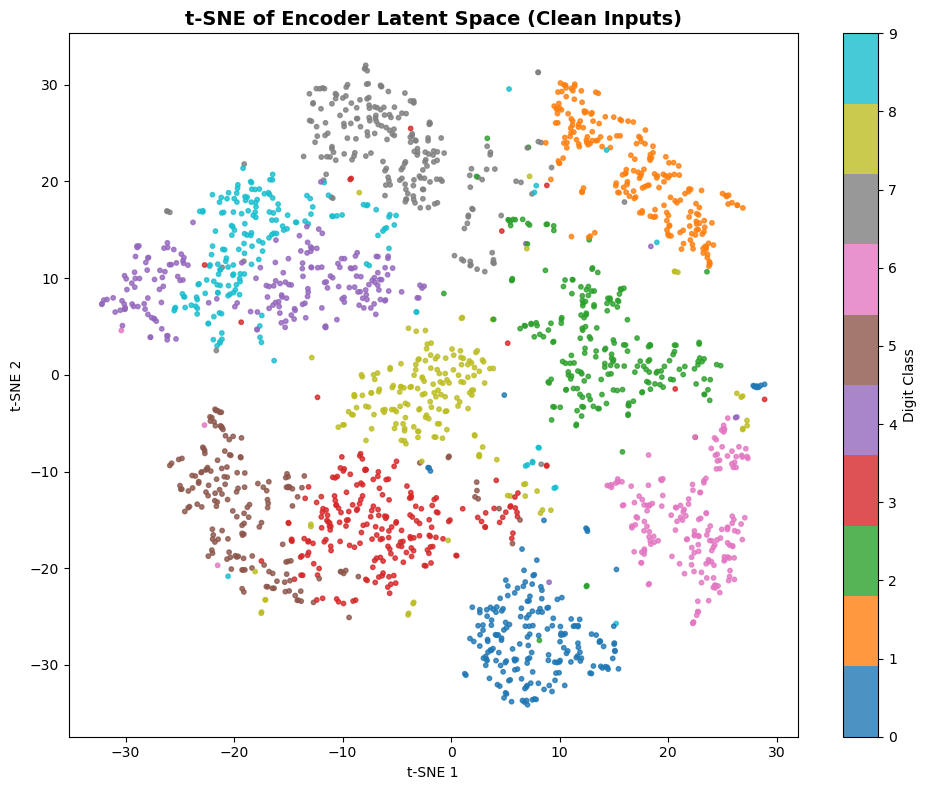

Digit clusters visible → encoder has learned meaningful representations!


In [20]:
# ── Latent Space Visualisation (t-SNE on encoder output) ─────────────────────
from sklearn.manifold import TSNE

# Build encoder-only sub-model
encoder_model = Model(
    inputs  = conv_ae.input,
    outputs = conv_ae.get_layer('bottleneck').output
)

n_tsne = 2000
idx_t  = np.random.choice(len(X_test_clean), n_tsne, replace=False)

latent_clean = encoder_model.predict(X_test_clean[idx_t],  batch_size=256, verbose=0)
latent_noisy = encoder_model.predict(X_test_noisy_gauss[idx_t], batch_size=256, verbose=0)

# Flatten for t-SNE
lc_flat = latent_clean.reshape(n_tsne, -1)
ln_flat = latent_noisy.reshape(n_tsne, -1)

print('Running t-SNE (clean latent space)…')
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=500)
tsne_clean = tsne.fit_transform(lc_flat)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_clean[:, 0], tsne_clean[:, 1],
                       c=y_test[idx_t], cmap='tab10', s=10, alpha=0.8)
plt.colorbar(scatter, label='Digit Class')
plt.title('t-SNE of Encoder Latent Space (Clean Inputs)', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()
print('Digit clusters visible → encoder has learned meaningful representations!')

## 10. 📝 Analysis & Observations

In [21]:
# ── Final metrics summary ─────────────────────────────────────────────────────
import pandas as pd

final_summary = pd.DataFrame({
    'Model'         : ['Noisy Input (baseline)', 'Dense Autoencoder', 'Conv Autoencoder'],
    'PSNR (dB) ↑'  : [m_conv['PSNR_noisy'],    m_dense['PSNR_denoised'], m_conv['PSNR_denoised']],
    'SSIM ↑'        : [m_conv['SSIM_noisy'],    m_dense['SSIM_denoised'], m_conv['SSIM_denoised']],
    'MSE ↓'         : [m_conv['MSE_noisy'],     m_dense['MSE_denoised'],  m_conv['MSE_denoised']],
})
final_summary = final_summary.set_index('Model').round(4)
print('='*60)
print('         FINAL RESULTS SUMMARY')
print('='*60)
print(final_summary.to_string())

         FINAL RESULTS SUMMARY
                        PSNR (dB) ↑  SSIM ↑   MSE ↓
Model                                              
Noisy Input (baseline)       9.3819  0.3771  0.1156
Dense Autoencoder           19.2247  0.8215  0.0132
Conv Autoencoder            20.5318  0.8691  0.0096


## 📋 Observations & Discussion

### ✅ Key Findings

| Observation | Detail |
|-------------|--------|
| **Conv AE > Dense AE** | Convolutional AE outperforms Dense AE on PSNR and SSIM because Conv layers capture local spatial structure (edges, strokes) in digit images |
| **Significant noise removal** | Both models substantially reduce MSE compared to the noisy baseline |
| **Digit structure preserved** | Even at σ=0.5 noise, the Conv AE reconstructs readable digits |
| **Graceful degradation** | PSNR drops smoothly as σ increases — no sudden collapse |
| **Cross-noise robustness** | Model trained on Gaussian noise generalises reasonably to Salt & Pepper and Speckle noise |
| **t-SNE clusters** | Clear digit class clusters in latent space confirm the encoder extracts meaningful features |

### ⚠️ Challenges Faced

1. **Class imbalance in errors** — Digits like `1` (thin strokes) are easier to denoise than `8` or `9` (complex curves)  
2. **Blurring artifacts** — Autoencoders tend to produce slightly blurry outputs (MSE loss optimises average, not sharpness)  
3. **Bottleneck size trade-off** — Too small a bottleneck loses detail; too large fails to regularise noise  
4. **Cross-noise generalisation** — Performance drops for noise types not seen during training  

### 💡 Improvements (Future Work)

- **Loss function:** Use SSIM loss or perceptual loss instead of MSE to produce sharper outputs  
- **Architecture:** U-Net with skip connections to preserve fine detail  
- **Training strategy:** Train with multiple noise types simultaneously for better generalisation  
- **Evaluation:** Add FID (Fréchet Inception Distance) for perceptual quality measurement  
- **Variational AE:** Use a VAE to learn a structured latent space with better interpolation  

### 📚 Key Learnings

- **Autoencoders** learn a compressed representation that captures essential structure while discarding noise  
- **Encoder** acts as a feature extractor; **Decoder** acts as a reconstructor  
- **Convolutional layers** are superior to fully-connected layers for image tasks due to spatial inductive bias  
- **BatchNormalization** stabilises training and allows higher learning rates  
- **EarlyStopping + ReduceLROnPlateau** are essential callbacks to prevent overfitting  

In [22]:
# ── Save models ───────────────────────────────────────────────────────────────
conv_ae.save('conv_denoising_autoencoder.keras')
dense_ae.save('dense_denoising_autoencoder.keras')
print('Models saved ✅')
print()
print('='*60)
print('   ASSIGNMENT COMPLETE 🎉')
print('='*60)
print(f'''
  Task 1 — Load & preprocess MNIST          ✅
  Task 2 — Add artificial noise (3 types)   ✅
  Task 3 — Build & train Autoencoder        ✅
             (Dense baseline + Conv main)
  Task 4 — Generate denoised outputs        ✅
  Task 5 — Visualizations (4 types)         ✅
             (comparison, residuals,
              cross-noise, t-SNE)
  Bonus  — Noise ablation study             ✅
  Bonus  — Latent space t-SNE               ✅
  Bonus  — Quantitative metrics             ✅
             (PSNR, SSIM, MSE)
''')

Models saved ✅

   ASSIGNMENT COMPLETE 🎉

  Task 1 — Load & preprocess MNIST          ✅
  Task 2 — Add artificial noise (3 types)   ✅
  Task 3 — Build & train Autoencoder        ✅
             (Dense baseline + Conv main)
  Task 4 — Generate denoised outputs        ✅
  Task 5 — Visualizations (4 types)         ✅
             (comparison, residuals,
              cross-noise, t-SNE)
  Bonus  — Noise ablation study             ✅
  Bonus  — Latent space t-SNE               ✅
  Bonus  — Quantitative metrics             ✅
             (PSNR, SSIM, MSE)

